<a href="https://colab.research.google.com/github/Raksh1707/Naturalproject/blob/main/nlpprct2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter

nltk.download('stopwords')
nltk.download('vader_lexicon')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
#step:1

data={
    "Review":[
        "The food was delicious and freshly prepared.",
        "Delivery was quick and the food arrived hot.",
        "Excellent customer service and friendly staff.",
        "The packaging was neat and secure.",
        "The portion size was too small for the price.",
        "The packaging leaked during delivery.",
        "The food quality was disappointing.",
        "The restaurant offers good value for money."


            ]
    }


df = pd.DataFrame(data)

print("Dataset review:")
print(df.head())



Dataset review:
                                           Review
0    The food was delicious and freshly prepared.
1    Delivery was quick and the food arrived hot.
2  Excellent customer service and friendly staff.
3              The packaging was neat and secure.
4   The portion size was too small for the price.


In [ ]:
#step:2

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['Clean_Review'] = df['Review'].apply(preprocess_text)

print("\nPreprocessed Reviews:")
print(df[['Review','Clean_Review']].head())


Preprocessed Reviews:
                                           Review  \
0    The food was delicious and freshly prepared.   
1    Delivery was quick and the food arrived hot.   
2  Excellent customer service and friendly staff.   
3              The packaging was neat and secure.   
4   The portion size was too small for the price.   

                                Clean_Review  
0            food delicious freshly prepared  
1            delivery quick food arrived hot  
2  excellent customer service friendly staff  
3                      packaging neat secure  
4                   portion size small price  


In [ ]:
#step:3

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df['Sentiment'] = df['Clean_Review'].apply(get_sentiment)

print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())


Sentiment Distribution:
Sentiment
Positive    4
Neutral     2
Negative    2
Name: count, dtype: int64


In [ ]:
#step:4

negative_reviews = df[df['Sentiment'] == 'Negative']

all_words = " ".join(negative_reviews['Clean_Review']).split()

common_issues = Counter(all_words).most_common(10)

print("\nTop Common Issues:")
for word, count in common_issues:
    print(word, ":", count)


Top Common Issues:
packaging : 1
leaked : 1
delivery : 1
food : 1
quality : 1
disappointing : 1


In [ ]:
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts

,count
Sentiment,
Positive,4
Neutral,2
Negative,2


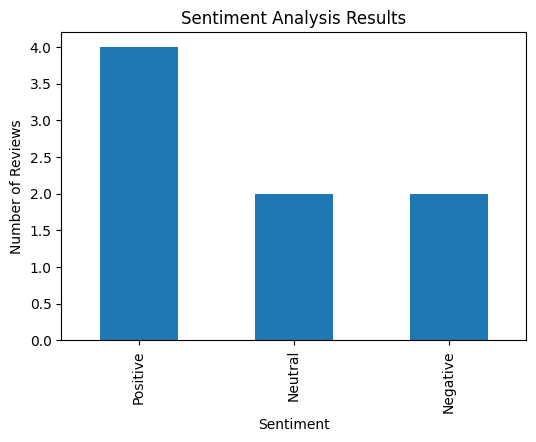

In [ ]:
plt.figure(figsize=(6,4))
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Analysis Results")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

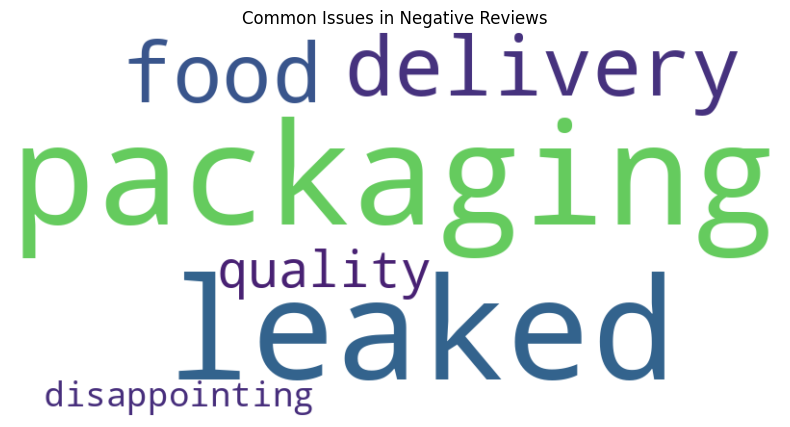

In [ ]:
negative_text = " ".join(negative_reviews['Clean_Review'])

if len(negative_text) > 0:
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white').generate(negative_text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Common Issues in Negative Reviews")
    plt.show()

In [ ]:
df.to_csv("restaurant_feedback_analysis_output.csv", index=False)

print("\nAnalysis completed successfully.")
print("Output saved as 'restaurant_feedback_analysis_output.csv'")


Analysis completed successfully.
Output saved as 'restaurant_feedback_analysis_output.csv'
